**Module 4**

---

**Problem 1**

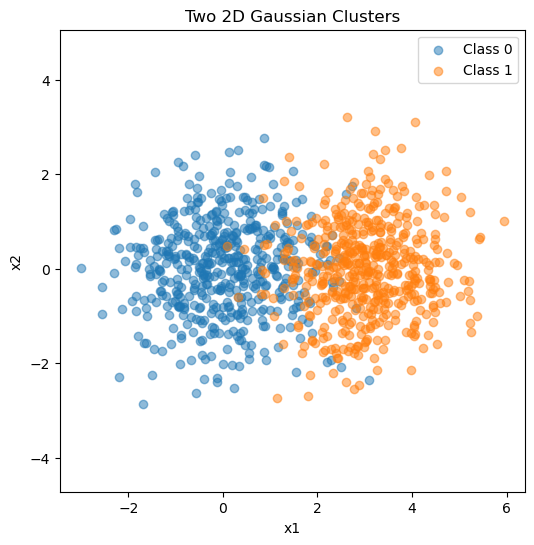

X shape: (1000, 2)
y shape: (1000,)


In [12]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from sklearn import datasets
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay,
    roc_curve, auc, accuracy_score
)


N = 500
mu0 = [0, 0]
mu1 = [3, 0]
cov = np.eye(2)

x0 = np.random.multivariate_normal(mu0, cov, N)
x1 = np.random.multivariate_normal(mu1, cov, N)

plt.figure(figsize=(6,6))
plt.scatter(x0[:,0], x0[:,1], label="Class 0", alpha=0.5)
plt.scatter(x1[:,0], x1[:,1], label="Class 1", alpha=0.5)

plt.xlabel("x1")
plt.ylabel("x2")
plt.title("Two 2D Gaussian Clusters")
plt.legend()
plt.axis("equal")
plt.show()



**Problem 2**

## Logistic Regression Classification

We train a logistic regression classifier to distinguish between two Gaussian clusters and visualize the decision boundary and probability regions.

---

### 1. Fit the classifier

We use `LogisticRegression` from `sklearn.linear_model` and fit the model to the dataset:

```python
model = LogisticRegression()
model.fit(X, Y)
```

Logistic regression learns a linear decision boundary of the form

$$
\textbf{w}^T\textbf{x} + b = 0
$$

This represents a straight line in 2D that separates the two classes.


### 2. Compute predicted probabilities on a grid

To visualize the classifier, we evaluate the model on a dense grid of points covering the data range.

```python
probs = model.predict_proba(grid)[:,1]
```

This gives the predicted probability

$$
P(y=1 \mid x)
$$

for each point in the grid. The probabilities are then reshaped to match the grid so they can be plotted.


### 3. Plot probability regions and decision boundary

We use `contourf` to shade the plane according to the predicted probability values. The shaded regions indicate the model's confidence in predicting each class. Regions with higher probability for class 1 are shaded differently from regions favoring class 0. 

The decision boundary occurs where the classifier is equally likely to predict either class:

$$
P(y=1 \mid x) = 0.5
$$

We draw this boundary using a contour line:

```python
plt.contour(xx, yy, probs, levels=[0.5])
```

This line represents the set of points where the classifier switches prediction from class 0 to class 1. In this dataset the two Gaussian clusters differ mainly in the $x_1$ direction, so the logistic regression model learns a boundary that is approximately vertical. 

X shape: (1000, 2)
Y shape: (1000,)


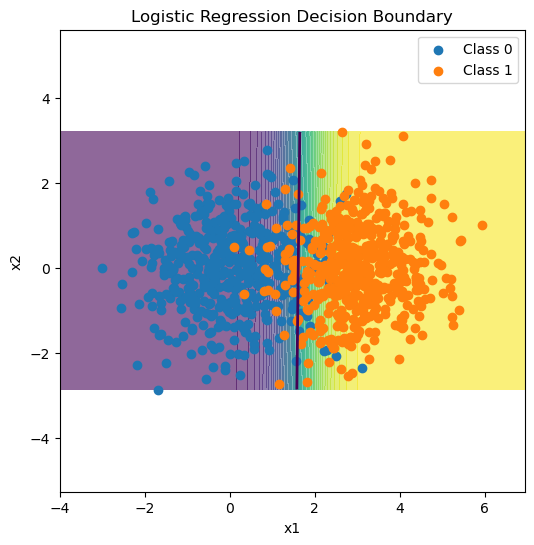

In [17]:
y0 = np.zeros(N)
y1 = np.ones(N)

X = np.vstack((x0, x1))
Y = np.concatenate((y0, y1))
print("X shape:", X.shape)
print("Y shape:", Y.shape)

# ----- Fit logistic regression -----
model = LogisticRegression()
model.fit(X, Y)

# ----- Create grid for probability shading -----
x_min, x_max = X[:,0].min() - 1, X[:,0].max() + 1
y_min, y_max = X[:,1].min() - 1, X[:,1].max() + 1

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 300),
    np.linspace(y_min, y_max, 300)
)

grid = np.c_[xx.ravel(), yy.ravel()]

# predicted probability for class 1
probs = model.predict_proba(grid)[:,1]
probs = probs.reshape(xx.shape)

# ----- Plot probability regions -----
plt.figure(figsize=(6,6))
plt.contourf(xx, yy, probs, levels=50, alpha=0.6)

# ----- Plot decision boundary -----
plt.contour(xx, yy, probs, levels=[0.5], linewidths=2)

# ----- Plot data points -----
plt.scatter(x0[:,0], x0[:,1], label="Class 0")
plt.scatter(x1[:,0], x1[:,1], label="Class 1")

plt.xlabel("x1")
plt.ylabel("x2")
plt.title("Logistic Regression Decision Boundary")
plt.legend()
plt.axis("equal")

plt.show()

**Problem 3**

In [27]:
y_pred = model.predict(X)

TP = np.sum((y_pred == 1) & (Y == 1))
TN = np.sum((y_pred == 0) & (Y == 0))
FP = np.sum((y_pred == 1) & (Y == 0))
FN = np.sum((y_pred == 0) & (Y == 1))

accuracy = (TP + TN) / len(Y)
fpr = FP / (FP + TN)
fnr = FN / (FN + TP)

print("Accuracy:", accuracy)
print("False Positive Rate:", fpr)
print("False Negative Rate:", fnr)

Accuracy: 0.605
False Positive Rate: 0.392
False Negative Rate: 0.398


m = 3
Accuracy: 0.923
False Positive Rate: 0.08
False Negative Rate: 0.074

m = 2
Accuracy: 0.835
False Positive Rate: 0.172
False Negative Rate: 0.158

m = 1
Accuracy: 0.699
False Positive Rate: 0.304
False Negative Rate: 0.298

m = 0.5
Accuracy: 0.604
False Positive Rate: 0.408
False Negative Rate: 0.384



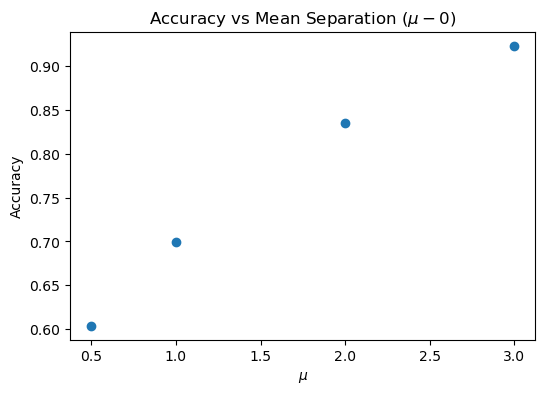

In [28]:
m_values = [3, 2, 1, 0.5]

accuracies = []
fpr_list = []
fnr_list = []

for m in m_values:
    mu1 = [m, 0]
    x1 = np.random.multivariate_normal(mu1, cov, N)

    y0 = np.zeros(N)
    y1 = np.ones(N)

    X = np.vstack((x0, x1))
    Y = np.concatenate((y0, y1))

    model = LogisticRegression()
    model.fit(X, Y)

    y_pred = model.predict(X)

    TP = np.sum((y_pred == 1) & (Y == 1))
    TN = np.sum((y_pred == 0) & (Y == 0))
    FP = np.sum((y_pred == 1) & (Y == 0))
    FN = np.sum((y_pred == 0) & (Y == 1))

    accuracy = (TP + TN) / len(y)
    fpr = FP / (FP + TN)
    fnr = FN / (FN + TP)

    accuracies.append(accuracy)
    fpr_list.append(fpr)
    fnr_list.append(fnr)

    print(f"m = {m}")
    print("Accuracy:", accuracy)
    print("False Positive Rate:", fpr)
    print("False Negative Rate:", fnr)
    print()

plt.figure(figsize=(6,4))
plt.scatter(m_values, accuracies)

plt.xlabel(r'$\mu$')
plt.ylabel("Accuracy")
plt.title("Accuracy vs Mean Separation $(\mu-0)$")
# plt.grid(True)
plt.show()

**Problem 4**

### 1. Why does performance degrade as $\mu \to 0$?

As $\mu$ decreases, the two distributions move closer together and their overlap increases. When the overlap is large, many data points from the two classes appear in the same region of feature space, making them harder to distinguish.


### 2. Does adding more data help when $\mu = 0$?

In the limit $\mu \to 0$, both classes are drawn from the same distribution. In this case, the features contain no information about the class label, so the classifier cannot separate the classes reliably and adding more data will not improve the performance. The best achievable performance is random guessing, which corresponds to an accuracy of about $50\%$.


### 3. What assumption does a linear classifier make about the data?

A linear classifier assumes that the classes can be separated by a linear decision boundary.

$$
\textbf{w}^T\textbf{x} + b = 0
$$

In 2D, this boundary is a line. In higher dimensions this boundary becomes a hyperplane.

For logistic regression, the probability of class membership is modeled as

$$
P(y=1|x) = \frac{1}{1 + e^{-(w^T x + b)}}
$$

This model produces a linear boundary in the feature space. If the true separation between classes is nonlinear, a linear classifier may struggle unless the input features are transformed or expanded.